# <font face = 'Spectral'>--- Journal 2 ---
## <font face = 'Spectral'>Entry 3

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Times New Roman'
plt.rc('font', size=18)

In [2]:
# creating values for x
x = np.linspace(0, 2*np.pi, 100)
a = 7.0
b = 7.7

In [3]:
# defining our mathematics function
def yuzz(a, b):
    result = a**(-b*x)
    return result

In [4]:
# setting values for y to graph in relation to x
y = yuzz(a, b)

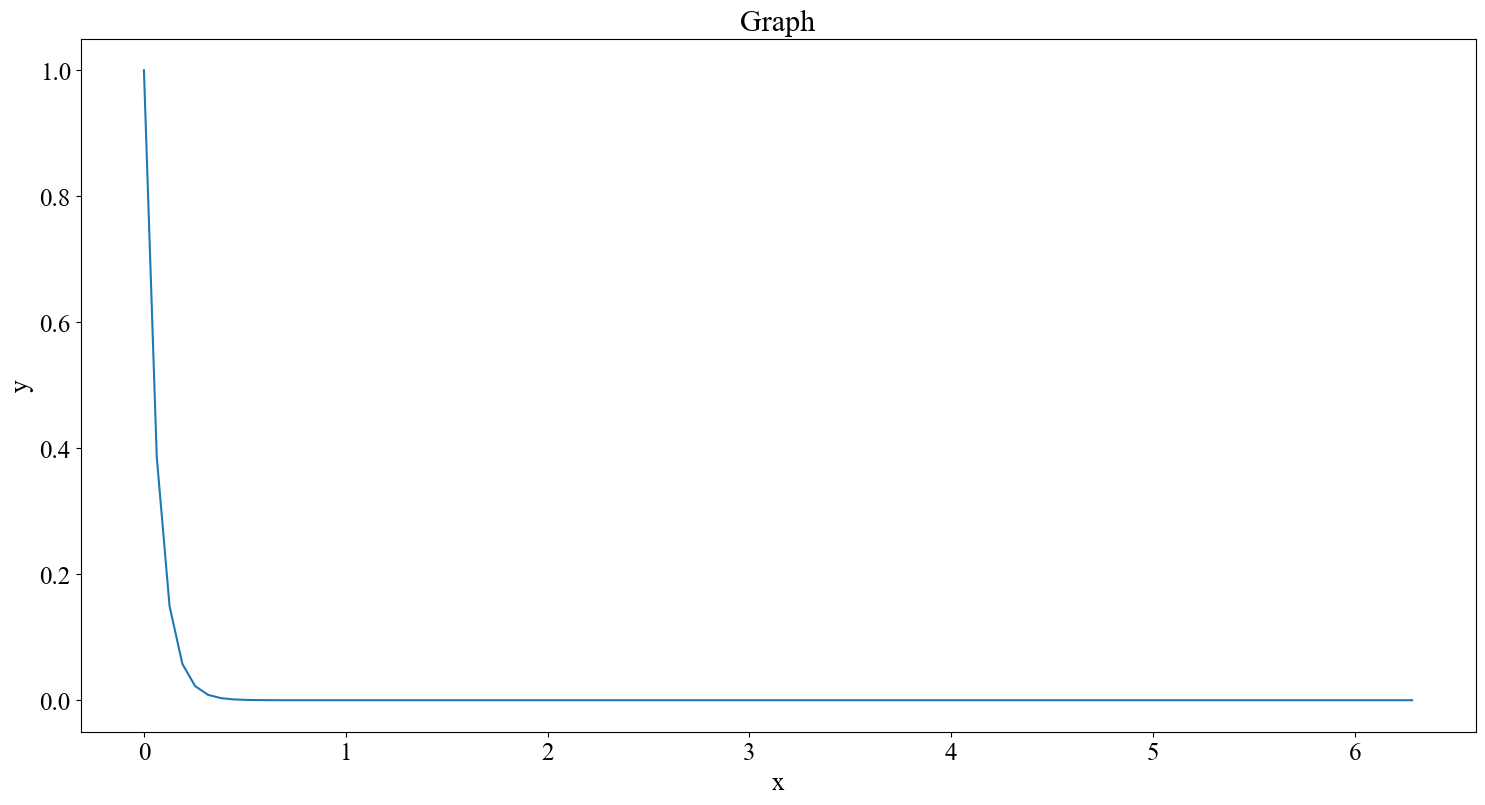

In [5]:
# creating the figure, plotting x vs. y
plt.figure(figsize=(18,9))
plt.plot(x, y, label='New')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Graph')

plt.savefig("journ2entr1.png", bbox_inches='tight')

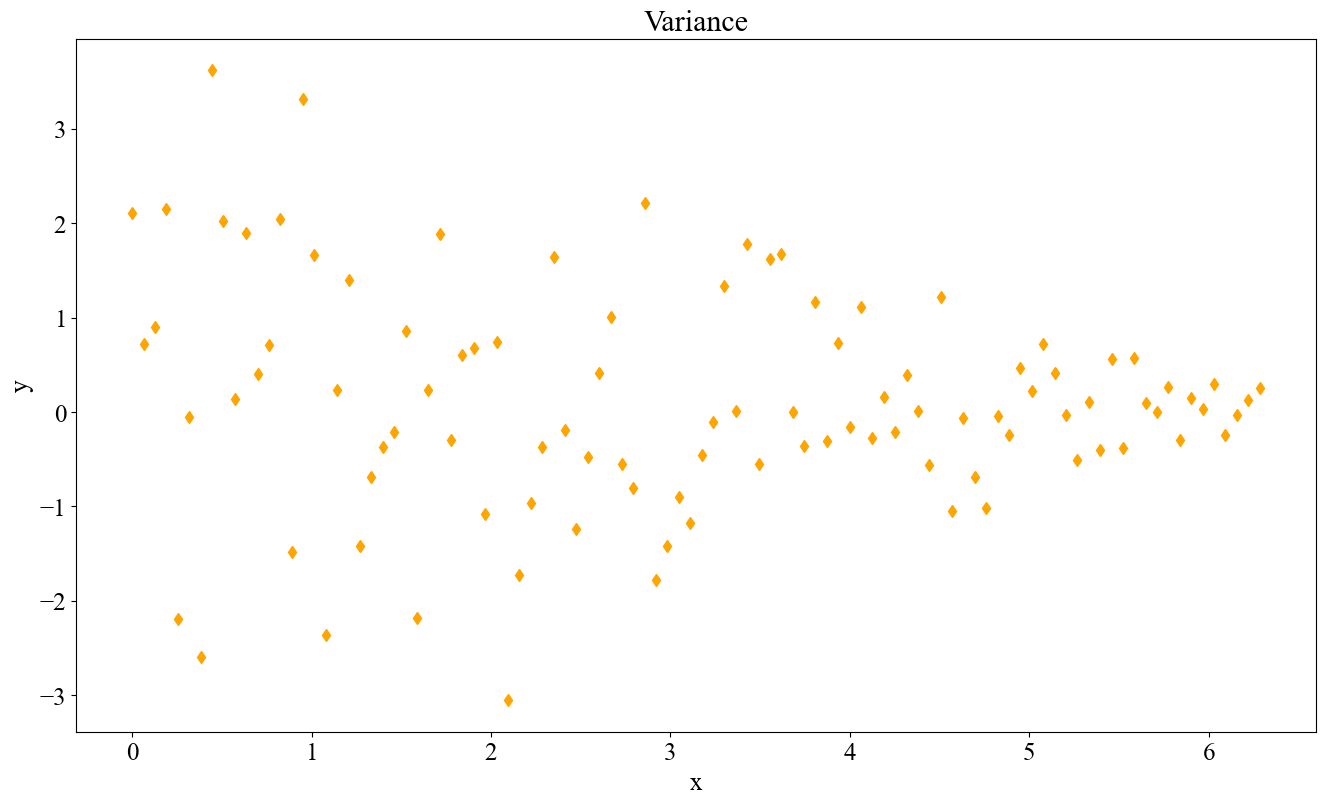

In [6]:
# adding scatter to the dataset
sigma = np.linspace(2.0, 0.2, 100)

# setting the new y values
y_new = y + np.random.normal(loc=0.0, scale=sigma)

plt.figure(figsize=(16,9))
plt.errorbar(x,
             y_new,
             fmt='d',
             c='orange'
            )
plt.xlabel('x'); plt.ylabel('y'); plt.title('Variance')

plt.savefig('journ2entr2.png', bbox_inches='tight')

/var/folders/7d/pbxbh8h95h786brn48csc_qc0000gp/T/ipykernel_73765/2228021681.py:8: RuntimeWarning: divide by zero encountered in divide
  return a / (x**b)
/var/folders/7d/pbxbh8h95h786brn48csc_qc0000gp/T/ipykernel_73765/2228021681.py:12: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_1, _ = curve_fit(model1, x, y_new, p0=[3, 0.4])
/var/folders/7d/pbxbh8h95h786brn48csc_qc0000gp/T/ipykernel_73765/1182685133.py:10: RuntimeWarning: divide by zero encountered in divide
  result = a / (x**b)


Exponential fit: a = 1.227, b = 1.668
Power law fit:   a = 3.000, b = 0.400


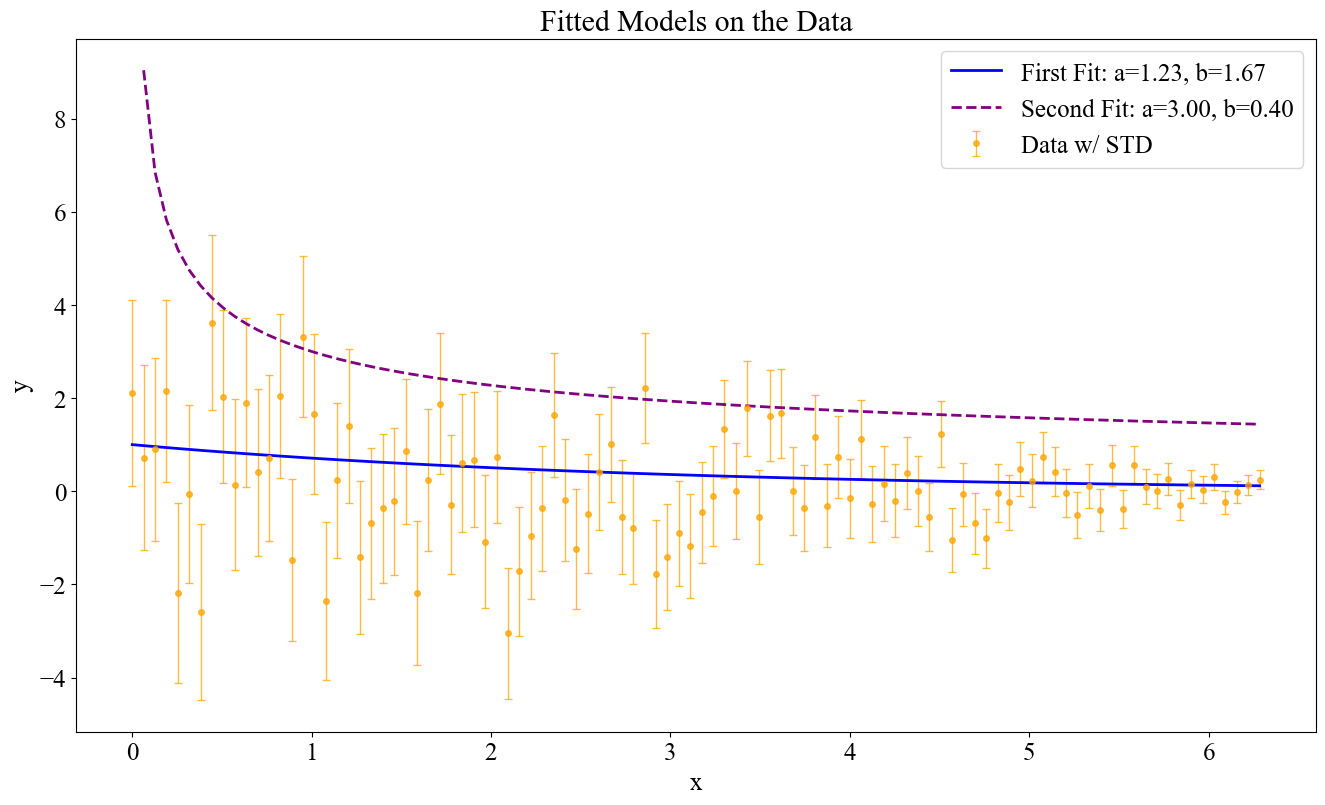

In [22]:
from scipy.optimize import curve_fit

# defining our two models
def model0(x, a, b):
    return a * np.exp(-b * x)

def model1(x, a, b):
    return a / (x**b)

# fitting both models
popt_0, _ = curve_fit(model0, x, y_new, p0=[3, 0.4])
popt_1, _ = curve_fit(model1, x, y_new, p0=[3, 0.4])

print(f"Exponential fit: a = {popt_0[0]:.3f}, b = {popt_0[1]:.3f}")
print(f"Power law fit:   a = {popt_1[0]:.3f}, b = {popt_1[1]:.3f}")

# plotting our data w/ both fits
fig, ax = plt.subplots(figsize=(16, 9))

ax.errorbar(x, 
            y_new, 
            yerr=sigma, 
            fmt='o', 
            color='orange',
            ecolor='orange', 
            elinewidth=1.0, 
            capsize=3,
            markersize=4, 
            alpha=0.75, 
            label='Data w/ STD'
           )

ax.plot(x, 
        model_0(x, *popt_0), 
        color='blue', 
        linewidth=2,
        label=f'First Fit: a={popt_0[0]:.2f}, b={popt_0[1]:.2f}'
       )

ax.plot(x, 
        model_1(x, *popt_1), 
        color='purple', 
        linewidth=2,
        linestyle='--', label=f'Second Fit: a={popt_1[0]:.2f}, b={popt_1[1]:.2f}'
       )

ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_title('Fitted Models on the Data')
ax.legend()

plt.savefig('journ2entr3.png', bbox_inches='tight')